# Sales Performance Analysis

In [395]:
import zipfile

with zipfile.ZipFile('/content/archive (2).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/task2_data')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [396]:
import os

for file in os.listdir('/content/task2_data'):
    print(file)

superstore_final_dataset (1).csv


In [397]:
import pandas as pd

file_path = '/content/task2_data/superstore_final_dataset (1).csv'

df = pd.read_csv(file_path, encoding='latin1')

print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)

df.head()

Dataset loaded successfully!
Rows and columns: (9800, 18)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [398]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [399]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64


In [400]:
# Fill missing Postal_Code values with 0
df['Postal_Code'] = df['Postal_Code'].fillna(0)

# Check missing values again
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Row_ID           0
Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Postal_Code      0
Region           0
Product_ID       0
Category         0
Sub_Category     0
Product_Name     0
Sales            0
dtype: int64


In [401]:
# Convert date columns to date format
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], dayfirst=True)

print("Date columns converted successfully!")
print(df[['Order_Date', 'Ship_Date']].dtypes)

Date columns converted successfully!
Order_Date    datetime64[ns]
Ship_Date     datetime64[ns]
dtype: object


In [402]:
# Calculate total sales (revenue)
total_sales = df['Sales'].sum()

print("Total Sales (Revenue):", total_sales)

Total Sales (Revenue): 2261536.7827000003


In [403]:
# Calculate Average Order Value (AOV)
total_orders = df['Order_ID'].nunique()
aov = total_sales / total_orders

print("Total Orders:", total_orders)
print("Average Order Value (AOV):", aov)

Total Orders: 4922
Average Order Value (AOV): 459.4751691791955


In [404]:
# Check all column names
print(df.columns.tolist())

['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales']


In [405]:
# Calculate total sales by category
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print("Sales by Category:")
print(sales_by_category)

Sales by Category:
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [406]:
# Calculate total sales by region
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print("Sales by Region:")
print(sales_by_region)

Sales by Region:
Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


In [407]:
# Find the top 10 products by sales
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)

print("Top 10 Products by Sales:")
print(top_products)

Top 10 Products by Sales:
Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [408]:
# Calculate monthly sales
monthly_sales = df.groupby(df['Order_Date'].dt.to_period('M'))['Sales'].sum()

print("Monthly Sales:")
print(monthly_sales)

Monthly Sales:
Order_Date
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     63133.6060
2016-10     31011.7375
2016-11     75249.3995
2016-12     74543.6012
2017-01     18542.4910
2017-02     22978.8150
2017-03     51165.0590
2017-04     38679.7670
2017-05     56656.9080
2017-06     39724.4860
2017-07     38320.7830
2017-08     30542.2003
2017-09     69193.3909
2017-10     59583.0330
2017-11     79066.4958
2017-12     95739.1210
2018-01     43476.4740
2018-02     19920.9974
2018-03     58863.4128
2018-04     35541.9101
2018-05     43825.9822
2018-06     48190.7277
2018-07 

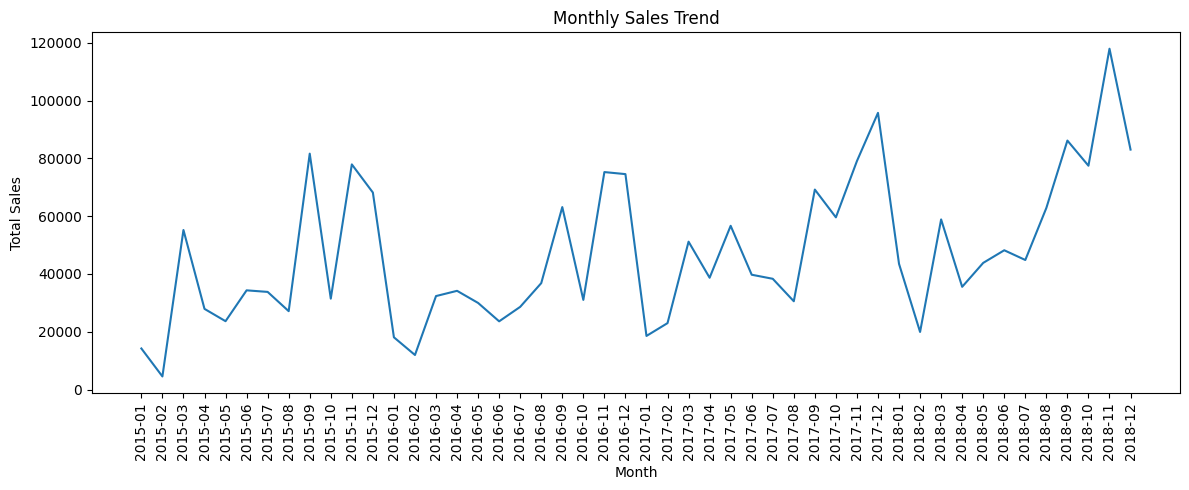

In [409]:
# Create a line chart for monthly sales

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [410]:
# Find the bottom 10 products by sales

bottom_products = df.groupby('Product_Name')['Sales'].sum().sort_values().head(10)

print("Bottom 10 Products by Sales:")
print(bottom_products)

Bottom 10 Products by Sales:
Product_Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Acme Serrated Blade Letter Opener                                   7.632
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink     7.800
Xerox 1989                                                          7.968
4009 Highlighters                                                   8.040
Stockwell Gold Paper Clips                                          8.096
Name: Sales, dtype: float64


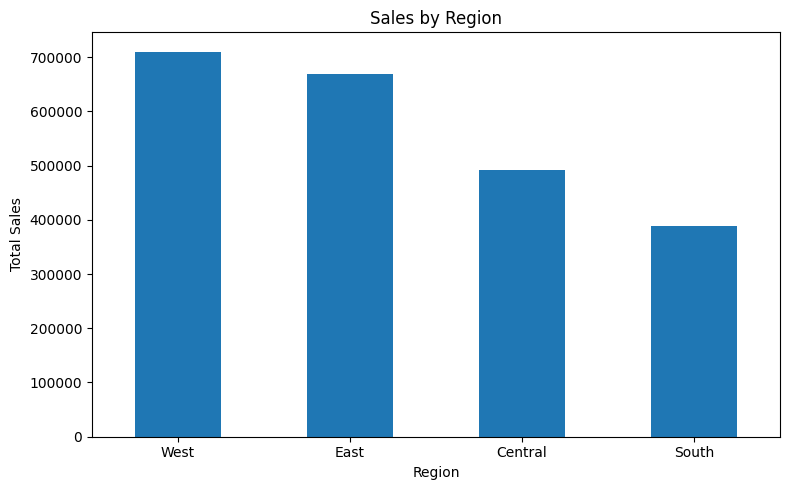

In [411]:
# Create a bar chart for sales by region

plt.figure(figsize=(8, 5))

sales_by_region.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

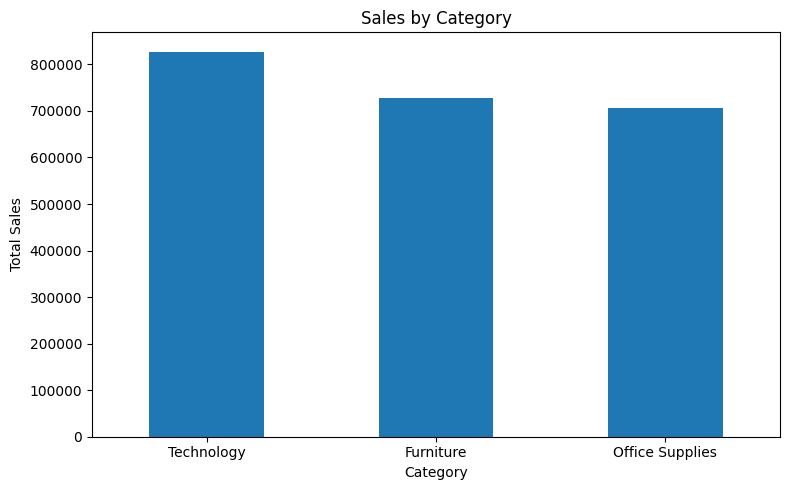

In [412]:
# Create a bar chart for sales by category

plt.figure(figsize=(8, 5))

sales_by_category.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

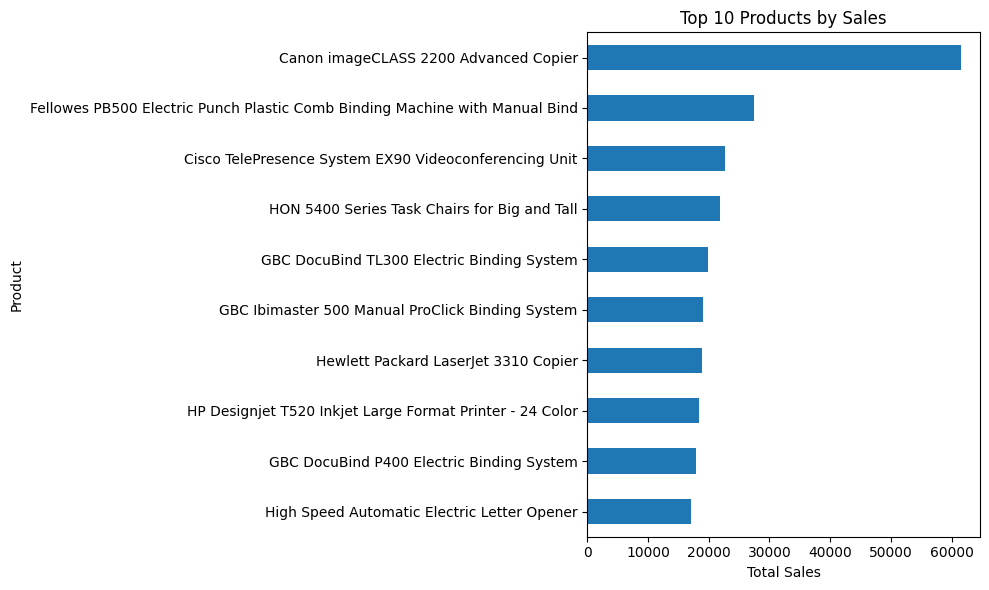

In [413]:
# Create a horizontal bar chart for the top 10 products

plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind='barh')

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [414]:
# Calculate total sales by customer segment

sales_by_segment = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

print("Sales by Customer Segment:")
print(sales_by_segment)

Sales by Customer Segment:
Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


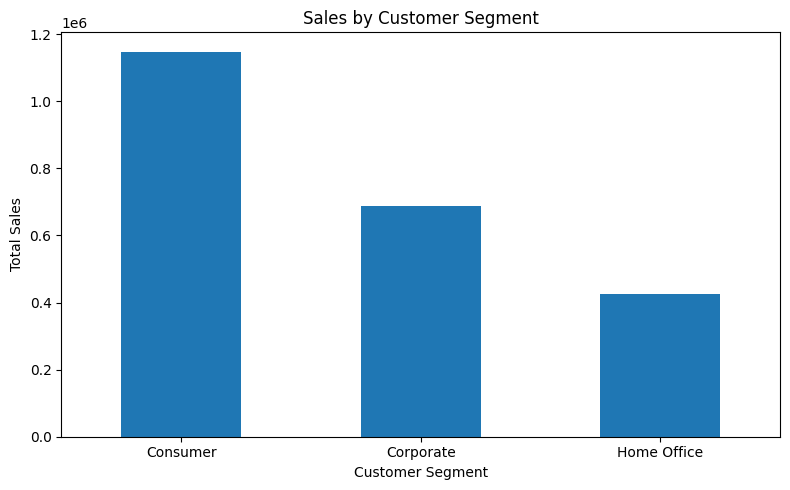

In [415]:
# Create a bar chart for sales by customer segment

plt.figure(figsize=(8, 5))

sales_by_segment.plot(kind='bar')

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [416]:
# Identify the highest and lowest performing regions

best_region = sales_by_region.idxmax()
best_region_sales = sales_by_region.max()

worst_region = sales_by_region.idxmin()
worst_region_sales = sales_by_region.min()

print("Best Performing Region:", best_region)
print("Sales:", best_region_sales)

print("\nWorst Performing Region:", worst_region)
print("Sales:", worst_region_sales)

Best Performing Region: West
Sales: 710219.6845

Worst Performing Region: South
Sales: 389151.459


In [417]:
# Identify the highest and lowest performing categories

best_category = sales_by_category.idxmax()
best_category_sales = sales_by_category.max()

worst_category = sales_by_category.idxmin()
worst_category_sales = sales_by_category.min()

print("Best Performing Category:", best_category)
print("Sales:", best_category_sales)

print("\nLowest Performing Category:", worst_category)
print("Sales:", worst_category_sales)

Best Performing Category: Technology
Sales: 827455.873

Lowest Performing Category: Office Supplies
Sales: 705422.334


In [418]:
# Calculate total sales by year

yearly_sales = df.groupby(df['Order_Date'].dt.year)['Sales'].sum()

print("Yearly Sales:")
print(yearly_sales)

Yearly Sales:
Order_Date
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64


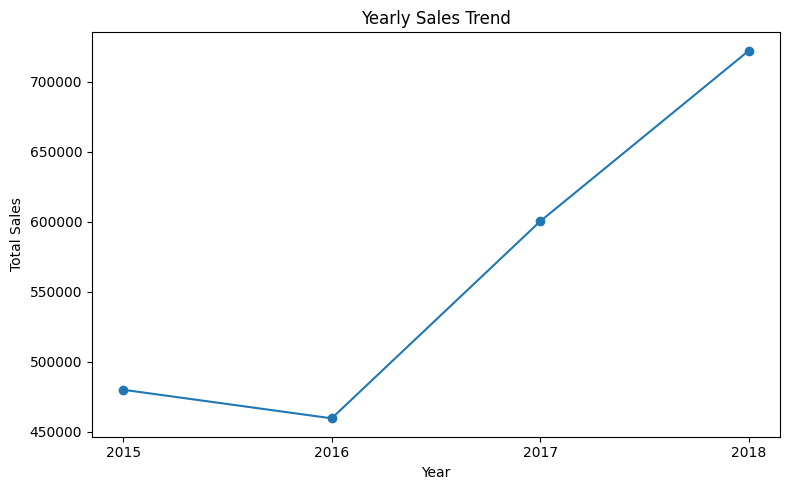

In [419]:
# Create a line chart for yearly sales

plt.figure(figsize=(8, 5))

yearly_sales.plot(kind='line', marker='o')

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(yearly_sales.index)

plt.tight_layout()
plt.show()

In [420]:
# Calculate total sales by shipping mode

sales_by_ship_mode = df.groupby('Ship_Mode')['Sales'].sum().sort_values(ascending=False)

print("Sales by Shipping Mode:")
print(sales_by_ship_mode)

Sales by Shipping Mode:
Ship_Mode
Standard Class    1.340831e+06
Second Class      4.499142e+05
First Class       3.455723e+05
Same Day          1.252190e+05
Name: Sales, dtype: float64


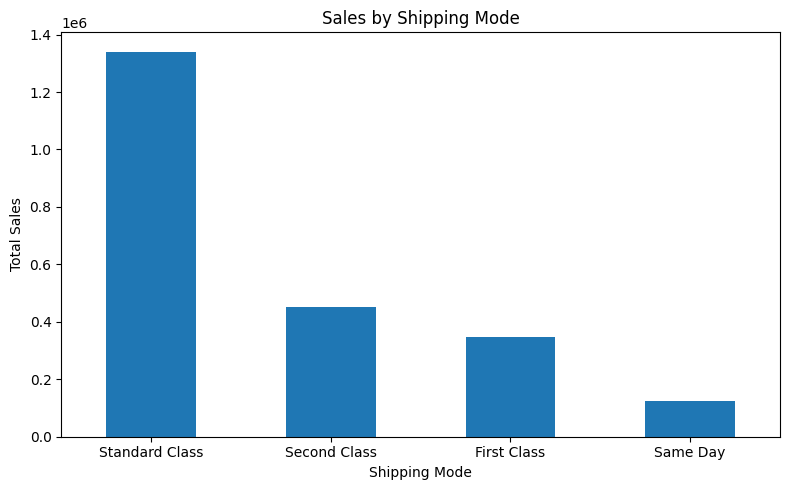

In [421]:
# Create a bar chart for sales by shipping mode

plt.figure(figsize=(8, 5))

sales_by_ship_mode.plot(kind='bar')

plt.title("Sales by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Key Findings

- Total sales were approximately **$2.26 million** across **4,922 orders**.
- The **Technology** category generated the highest sales, at approximately **$827,456**.
- The **West** region had the highest sales, at approximately **$710,220**, while the **South** region had the lowest, at approximately **$389,151**.
- The **Consumer** segment generated the highest sales, at approximately **$1.15 million**.
- Sales increased from **2016 to 2018**, with **2018** recording the highest yearly sales of approximately **$722,052**.
- **November 2018** had the highest monthly sales, at approximately **$117,938**.
- The **Canon imageCLASS 2200 Advanced Copier** was the top-selling product by total sales.
- Standard Class shipping was associated with the highest sales volume among the shipping modes.

## 5 Tactical Improvements

1. **Increase focus on Technology products:** Technology generated the highest sales, so the company can maintain strong inventory and targeted promotions for high-performing technology products.

2. **Improve performance in the South region:** The South region had the lowest sales among the four regions. The company can investigate customer demand and introduce region-specific promotions to increase sales.

3. **Promote high-performing products:** Products such as the Canon imageCLASS 2200 Advanced Copier generated high sales. Similar high-value products can receive additional promotional support.

4. **Use seasonal sales patterns:** Sales were particularly high in November and December in several years. The company can plan inventory and marketing campaigns ahead of these high-sales periods.

5. **Strengthen Consumer-segment marketing:** The Consumer segment generated the highest sales. Targeted offers, loyalty programs, and personalized promotions can be used to maintain and increase sales from this segment.

## Conclusion

The Sales Performance Analysis provided an overview of sales across products, categories, regions, customer segments, and time periods. Total sales were approximately $2.26 million from 4,922 orders. Technology was the highest-selling category, while the West region generated the highest regional sales. The Consumer segment contributed the largest share of sales. Yearly sales also showed strong growth from 2016 to 2018, with 2018 recording the highest annual sales. These findings can help the company improve regional performance, focus on high-performing products and categories, plan for seasonal demand, and develop targeted customer marketing strategies.